# T11J Top Wavelength Tables

T11A〜T11I 系の outputs に保存されている interpretability 結果から、PNG ではなく具体的な波長と数値を表で確認する notebook。

主に `outputs/heatmaps`, `outputs/saliency`, `outputs/integrated_gradients`, `outputs/occlusion` の CSV を集約します。

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "T11_top_wavelength_tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUTPUT_DIR =", OUTPUT_DIR)

PROJECT_ROOT = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D
OUTPUT_DIR = C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables


## Settings And Helpers

In [2]:
TASK_TO_T11 = {
    "mc": "T11A_train_mc + T11F_interpretability",
    "species": "T11B_train_species + T11F_interpretability",
    "woodtype": "T11C_train_woodtype + T11F_interpretability",
    "index_norm": "T11D_train_index_norm + T11F_interpretability",
    "mc_norm": "T11E_train_mc_norm + T11F_interpretability",
    "wood_structure": "T11H_train_wood_structure + T11F_interpretability",
}
TASK_RELEVANCE = {
    "mc": "direct_moisture_prediction",
    "mc_norm": "direct_moisture_prediction_normalized",
    "index_norm": "moisture_related_index_normalization",
    "species": "indirect_species_context",
    "woodtype": "indirect_woodtype_context",
    "wood_structure": "indirect_structure_context",
}
MOISTURE_TASKS = {"mc", "mc_norm", "index_norm"}

WAVELENGTH_NOTES = [
    (970, "water O-H overtone / low NIR"),
    (1200, "transport / optical path region"),
    (1450, "water absorption"),
    (1720, "C-H / bound-water related region"),
    (1900, "strong water absorption"),
    (2100, "structure / cellulose-lignin slope"),
    (2250, "structure / lignin-cellulose region"),
]


def task_from_name(name: str) -> str:
    stem = Path(name).stem
    for suffix in [
        "_integrated_gradients_mean",
        "_saliency_mean",
        "_importance",
        "_band_occlusion",
        "_channel_occlusion",
    ]:
        if stem.endswith(suffix):
            return stem[: -len(suffix)]
    return stem


def method_from_path(path: Path) -> str:
    text = str(path).replace("\\", "/")
    name = path.name
    if "/heatmaps/" in text and name.endswith("_importance.csv"):
        return "combined_importance_saliency_ig"
    if "/saliency/" in text and name.endswith("_saliency_mean.csv"):
        return "gradient_saliency"
    if "/integrated_gradients/" in text and name.endswith("_integrated_gradients_mean.csv"):
        return "integrated_gradients"
    if "/occlusion/" in text and name.endswith("_band_occlusion.csv"):
        return "band_occlusion"
    return "unknown"


PREPROCESS_VIEW_MAP = {
    "raw": "raw",
    "x_raw": "raw",
    "snv": "snv",
    "x_snv": "snv",
    "sg1": "raw_sg1",
    "raw_sg1": "raw_sg1",
    "x_raw_sg1": "raw_sg1",
    "sg2": "raw_sg2",
    "raw_sg2": "raw_sg2",
    "x_raw_sg2": "raw_sg2",
    "snv_sg1": "snv_sg1",
    "x_snv_sg1": "snv_sg1",
    "snv_sg2": "snv_sg2",
    "x_snv_sg2": "snv_sg2",
    "all_views_mean": "all_preprocess_mean",
}


def infer_preprocess_from_view(view) -> str:
    text = str(view).strip().lower().replace("-", "_")
    return PREPROCESS_VIEW_MAP.get(text, text if text and text != "nan" else "unknown")


def infer_feature_family(preprocess: str) -> str:
    p = str(preprocess).lower()
    if p == "raw":
        return "raw_reflectance"
    if p == "snv":
        return "snv_normalized"
    if p in {"raw_sg1", "sg1"}:
        return "raw_first_derivative_sg1"
    if p in {"raw_sg2", "sg2"}:
        return "raw_second_derivative_sg2"
    if p == "snv_sg1":
        return "snv_first_derivative_sg1"
    if p == "snv_sg2":
        return "snv_second_derivative_sg2"
    if p in {"all_preprocess_mean", "mixed_preprocess", "input_tensor_all_views"}:
        return "mixed_preprocess_views"
    return "unknown"


def add_preprocess_columns(df: pd.DataFrame, default_preprocess: str | None = None) -> pd.DataFrame:
    out = df.copy()
    if "preprocess" not in out.columns:
        if "view" in out.columns:
            out["preprocess"] = out["view"].map(infer_preprocess_from_view)
        else:
            out["preprocess"] = default_preprocess or "input_tensor_all_views"
    if default_preprocess is not None:
        out["preprocess"] = out["preprocess"].fillna(default_preprocess)
    if "feature_family" not in out.columns:
        out["feature_family"] = out["preprocess"].map(infer_feature_family)
    return out


def nearest_note(wavelength: float) -> str:
    nearest, note = min(WAVELENGTH_NOTES, key=lambda x: abs(float(wavelength) - x[0]))
    delta = abs(float(wavelength) - nearest)
    return f"{note} (~{nearest}nm, Δ{delta:.1f}nm)"


def savefig(name: str) -> Path:
    path = FIGURE_DIR / name
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print("saved:", path)
    return path


def add_common_columns(df: pd.DataFrame, task: str, method: str, source_file: Path) -> pd.DataFrame:
    out = df.copy()
    out.insert(0, "source_file", str(source_file.relative_to(PROJECT_ROOT)))
    out.insert(0, "task_relevance", TASK_RELEVANCE.get(task, "unknown"))
    out.insert(0, "task", task)
    out.insert(0, "method", method)
    out.insert(0, "experiment", TASK_TO_T11.get(task, "unknown_T11_output"))
    return out

## Extract Top Wavelengths From Importance CSV

In [3]:
importance_files = []
importance_files += sorted((PROJECT_ROOT / "outputs" / "heatmaps").glob("*_importance.csv"))
importance_files += sorted((PROJECT_ROOT / "outputs" / "saliency").glob("*_saliency_mean.csv"))
importance_files += sorted((PROJECT_ROOT / "outputs" / "integrated_gradients").glob("*_integrated_gradients_mean.csv"))

print("importance files:", len(importance_files))
for p in importance_files:
    print("-", p.relative_to(PROJECT_ROOT))

importance files: 17
- outputs\heatmaps\index_norm_importance.csv
- outputs\heatmaps\mc_importance.csv
- outputs\heatmaps\mc_norm_importance.csv
- outputs\heatmaps\species_importance.csv
- outputs\heatmaps\woodtype_importance.csv
- outputs\saliency\index_norm_saliency_mean.csv
- outputs\saliency\mc_norm_saliency_mean.csv
- outputs\saliency\mc_saliency_mean.csv
- outputs\saliency\species_saliency_mean.csv
- outputs\saliency\wood_structure_saliency_mean.csv
- outputs\saliency\woodtype_saliency_mean.csv
- outputs\integrated_gradients\index_norm_integrated_gradients_mean.csv
- outputs\integrated_gradients\mc_integrated_gradients_mean.csv
- outputs\integrated_gradients\mc_norm_integrated_gradients_mean.csv
- outputs\integrated_gradients\species_integrated_gradients_mean.csv
- outputs\integrated_gradients\wood_structure_integrated_gradients_mean.csv
- outputs\integrated_gradients\woodtype_integrated_gradients_mean.csv


In [4]:
def top_view_wavelength_points(path: Path, top_n: int = 30) -> pd.DataFrame:
    df = pd.read_csv(path, engine="python")
    task = task_from_name(path.name)
    method = method_from_path(path)
    work = df.dropna(subset=["wavelength", "importance"]).copy()
    work["score"] = work["importance"].astype(float)
    work = work.sort_values("score", ascending=False).head(top_n).reset_index(drop=True)
    work.insert(0, "rank", np.arange(1, len(work) + 1))
    work["wavelength_nm"] = work["wavelength"].astype(float)
    work["wavelength_note"] = work["wavelength_nm"].map(nearest_note)
    work["aggregation"] = "view_wavelength_point"
    work = add_preprocess_columns(work)
    work = work[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_common_columns(work, task, method, path)


def top_wavelength_mean(path: Path, top_n: int = 30) -> pd.DataFrame:
    df = pd.read_csv(path, engine="python")
    task = task_from_name(path.name)
    method = method_from_path(path)
    wave = (
        df.dropna(subset=["wavelength", "importance"])
        .groupby("wavelength", as_index=False)["importance"]
        .mean()
        .rename(columns={"importance": "score"})
        .sort_values("score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    wave.insert(0, "rank", np.arange(1, len(wave) + 1))
    wave["wavelength_nm"] = wave["wavelength"].astype(float)
    wave["wavelength_note"] = wave["wavelength_nm"].map(nearest_note)
    wave["aggregation"] = "mean_across_views"
    wave["view"] = "all_views_mean"
    wave["importance"] = wave["score"]
    wave = add_preprocess_columns(wave, default_preprocess="all_preprocess_mean")
    wave = wave[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_common_columns(wave, task, method, path)


def top_wavelength_peaks(path: Path, top_n: int = 15, min_distance_nm: float = 20.0) -> pd.DataFrame:
    df = pd.read_csv(path, engine="python")
    task = task_from_name(path.name)
    method = method_from_path(path)
    wave = (
        df.dropna(subset=["wavelength", "importance"])
        .groupby("wavelength", as_index=False)["importance"]
        .mean()
        .rename(columns={"importance": "score"})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
    selected = []
    for _, row in wave.iterrows():
        w = float(row["wavelength"])
        if all(abs(w - float(prev["wavelength_nm"])) >= min_distance_nm for prev in selected):
            selected.append({"wavelength_nm": w, "score": float(row["score"])})
        if len(selected) >= top_n:
            break
    out = pd.DataFrame(selected)
    if out.empty:
        return out
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    out["aggregation"] = f"peak_mean_across_views_min_{min_distance_nm:g}nm"
    out["view"] = "all_views_mean"
    out["importance"] = out["score"]
    out["wavelength_note"] = out["wavelength_nm"].map(nearest_note)
    out = add_preprocess_columns(out, default_preprocess="all_preprocess_mean")
    out = out[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_common_columns(out, task, method, path)


def top_wavelength_peaks_by_preprocess(path: Path, top_n: int = 12, min_distance_nm: float = 20.0) -> pd.DataFrame:
    df = pd.read_csv(path, engine="python")
    task = task_from_name(path.name)
    method = method_from_path(path)
    rows = []
    for view, sub in df.dropna(subset=["view", "wavelength", "importance"]).groupby("view"):
        wave = (
            sub.groupby("wavelength", as_index=False)["importance"]
            .mean()
            .rename(columns={"importance": "score"})
            .sort_values("score", ascending=False)
            .reset_index(drop=True)
        )
        selected = []
        for _, row in wave.iterrows():
            w = float(row["wavelength"])
            if all(abs(w - float(prev["wavelength_nm"])) >= min_distance_nm for prev in selected):
                selected.append({"view": view, "wavelength_nm": w, "score": float(row["score"])})
            if len(selected) >= top_n:
                break
        rows.extend(selected)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out = add_preprocess_columns(out)
    out["rank"] = out.groupby("preprocess")["score"].rank(method="first", ascending=False).astype(int)
    out["aggregation"] = f"peak_by_preprocess_min_{min_distance_nm:g}nm"
    out["importance"] = out["score"]
    out["wavelength_note"] = out["wavelength_nm"].map(nearest_note)
    out = out.sort_values(["preprocess", "rank"]).reset_index(drop=True)
    out = out[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_common_columns(out, task, method, path)


top_point_tables = [top_view_wavelength_points(p, top_n=50) for p in importance_files]
top_mean_tables = [top_wavelength_mean(p, top_n=50) for p in importance_files]
top_peak_tables = [top_wavelength_peaks(p, top_n=20, min_distance_nm=20.0) for p in importance_files]
top_peak_by_preprocess_tables = [top_wavelength_peaks_by_preprocess(p, top_n=12, min_distance_nm=20.0) for p in importance_files]

top_points = pd.concat(top_point_tables, ignore_index=True)
top_wavelengths_mean = pd.concat(top_mean_tables, ignore_index=True)
top_peaks = pd.concat(top_peak_tables, ignore_index=True)
top_peaks_by_preprocess = pd.concat(top_peak_by_preprocess_tables, ignore_index=True)

top_points.to_csv(OUTPUT_DIR / "T11_top_view_wavelength_points.csv", index=False, encoding="utf-8-sig")
top_wavelengths_mean.to_csv(OUTPUT_DIR / "T11_top_wavelengths_mean_across_views.csv", index=False, encoding="utf-8-sig")
top_peaks.to_csv(OUTPUT_DIR / "T11_top_wavelength_peaks.csv", index=False, encoding="utf-8-sig")
top_peaks_by_preprocess.to_csv(OUTPUT_DIR / "T11_top_wavelength_peaks_by_preprocess.csv", index=False, encoding="utf-8-sig")

display(top_peaks.head(30))
print("saved:", OUTPUT_DIR / "T11_top_view_wavelength_points.csv")
print("saved:", OUTPUT_DIR / "T11_top_wavelengths_mean_across_views.csv")
print("saved:", OUTPUT_DIR / "T11_top_wavelength_peaks.csv")
print("saved:", OUTPUT_DIR / "T11_top_wavelength_peaks_by_preprocess.csv")

,experiment,method,task,task_relevance,source_file,rank,aggregation,view,preprocess,feature_family,wavelength_nm,score,importance,wavelength_note
0,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,1,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2064.184530,0.280039,0.280039,"structure / cellulose-lignin slope (~2100nm, Δ..."
1,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,2,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2423.005393,0.271065,0.271065,"structure / lignin-cellulose region (~2250nm, ..."
2,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,3,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2022.321192,0.266433,0.266433,"structure / cellulose-lignin slope (~2100nm, Δ..."
3,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,4,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2321.052611,0.254717,0.254717,"structure / lignin-cellulose region (~2250nm, ..."
4,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,5,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,1458.164098,0.251107,0.251107,"water absorption (~1450nm, Δ8.2nm)"
5,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,6,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2100.985225,0.242971,0.242971,"structure / cellulose-lignin slope (~2100nm, Δ..."
6,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,7,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2382.918902,0.230834,0.230834,"structure / lignin-cellulose region (~2250nm, ..."
7,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,8,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2121.616831,0.227614,0.227614,"structure / cellulose-lignin slope (~2100nm, Δ..."
8,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,9,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2043.038431,0.221570,0.221570,"structure / cellulose-lignin slope (~2100nm, Δ..."
9,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,10,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,1478.959365,0.217751,0.217751,"water absorption (~1450nm, Δ29.0nm)"


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\T11_top_view_wavelength_points.csv
saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\T11_top_wavelengths_mean_across_views.csv
saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\T11_top_wavelength_peaks.csv
saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\T11_top_wavelength_peaks_by_preprocess.csv


## Extract Occlusion Band Tables

In [5]:
def parse_band(band: str) -> tuple[float, float, float]:
    m = re.match(r"([0-9.]+)-([0-9.]+)", str(band))
    if not m:
        return math.nan, math.nan, math.nan
    low = float(m.group(1))
    high = float(m.group(2))
    return low, high, (low + high) / 2.0


band_files = sorted((PROJECT_ROOT / "outputs" / "occlusion").glob("*_band_occlusion.csv"))
band_tables = []
for path in band_files:
    df = pd.read_csv(path, engine="python")
    task = task_from_name(path.name)
    method = method_from_path(path)
    work = df.copy()
    parsed = work["band"].map(parse_band)
    work["band_low_nm"] = [x[0] for x in parsed]
    work["band_high_nm"] = [x[1] for x in parsed]
    work["wavelength_nm"] = [x[2] for x in parsed]
    work["prediction_drop"] = pd.to_numeric(work["prediction_drop"], errors="coerce")
    work["score"] = work["prediction_drop"].abs()
    work = work.sort_values("score", ascending=False).reset_index(drop=True)
    work.insert(0, "rank", np.arange(1, len(work) + 1))
    work["aggregation"] = "occlusion_band_abs_prediction_drop"
    work["wavelength_note"] = work["wavelength_nm"].map(nearest_note)
    work = add_preprocess_columns(work, default_preprocess="input_tensor_all_views")
    work = work[["rank", "aggregation", "preprocess", "feature_family", "band", "band_low_nm", "band_high_nm", "wavelength_nm", "prediction_drop", "score", "wavelength_note"]]
    band_tables.append(add_common_columns(work, task, method, path))

band_occlusion_summary = pd.concat(band_tables, ignore_index=True) if band_tables else pd.DataFrame()
band_occlusion_summary.to_csv(OUTPUT_DIR / "T11_band_occlusion_ranked.csv", index=False, encoding="utf-8-sig")
display(band_occlusion_summary.head(30))
print("saved:", OUTPUT_DIR / "T11_band_occlusion_ranked.csv")

,experiment,method,task,task_relevance,source_file,rank,aggregation,preprocess,feature_family,band,band_low_nm,band_high_nm,wavelength_nm,prediction_drop,score,wavelength_note
0,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,1,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1300-1600,1300.0,1600.0,1450.0,-0.354462,0.354462,"water absorption (~1450nm, Δ0.0nm)"
1,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,2,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2000-2300,2000.0,2300.0,2150.0,-0.244782,0.244782,"structure / cellulose-lignin slope (~2100nm, Δ..."
2,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,3,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1000-1300,1000.0,1300.0,1150.0,-0.120059,0.120059,"transport / optical path region (~1200nm, Δ50...."
3,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,4,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1800-2000,1800.0,2000.0,1900.0,-0.098092,0.098092,"strong water absorption (~1900nm, Δ0.0nm)"
4,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,5,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2300-2500,2300.0,2500.0,2400.0,-0.082214,0.082214,"structure / lignin-cellulose region (~2250nm, ..."
5,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,6,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1600-1800,1600.0,1800.0,1700.0,-0.020310,0.020310,"C-H / bound-water related region (~1720nm, Δ20..."
6,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,1,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1000-1300,1000.0,1300.0,1150.0,-47.926052,47.926052,"transport / optical path region (~1200nm, Δ50...."
7,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,2,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1800-2000,1800.0,2000.0,1900.0,-7.895563,7.895563,"strong water absorption (~1900nm, Δ0.0nm)"
8,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,3,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2000-2300,2000.0,2300.0,2150.0,-7.289633,7.289633,"structure / cellulose-lignin slope (~2100nm, Δ..."
9,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,4,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1300-1600,1300.0,1600.0,1450.0,-7.017177,7.017177,"water absorption (~1450nm, Δ0.0nm)"


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\T11_band_occlusion_ranked.csv


## Moisture-Focused Summary Tables

In [6]:
moisture_top_peaks = top_peaks[top_peaks["task"].isin(MOISTURE_TASKS)].copy()
moisture_top_peaks_by_preprocess = top_peaks_by_preprocess[top_peaks_by_preprocess["task"].isin(MOISTURE_TASKS)].copy()
moisture_top_points = top_points[top_points["task"].isin(MOISTURE_TASKS)].copy()
moisture_band_occlusion = band_occlusion_summary[band_occlusion_summary["task"].isin(MOISTURE_TASKS)].copy()

moisture_top_peaks.to_csv(OUTPUT_DIR / "T11_moisture_tasks_top_wavelength_peaks.csv", index=False, encoding="utf-8-sig")
moisture_top_peaks_by_preprocess.to_csv(OUTPUT_DIR / "T11_moisture_tasks_top_wavelength_peaks_by_preprocess.csv", index=False, encoding="utf-8-sig")
moisture_top_points.to_csv(OUTPUT_DIR / "T11_moisture_tasks_top_view_wavelength_points.csv", index=False, encoding="utf-8-sig")
moisture_band_occlusion.to_csv(OUTPUT_DIR / "T11_moisture_tasks_band_occlusion_ranked.csv", index=False, encoding="utf-8-sig")

display(moisture_top_peaks_by_preprocess.head(80))
display(moisture_top_peaks.head(30))
display(moisture_band_occlusion.head(30))

,experiment,method,task,task_relevance,source_file,rank,aggregation,view,preprocess,feature_family,wavelength_nm,score,importance,wavelength_note
0,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,1,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,1458.984675,0.328760,0.328760,"water absorption (~1450nm, Δ9.0nm)"
1,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,2,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,1479.803520,0.305314,0.305314,"water absorption (~1450nm, Δ29.8nm)"
2,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,3,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,2387.307336,0.300814,0.300814,"structure / lignin-cellulose region (~2250nm, ..."
3,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,4,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,2100.985225,0.293578,0.293578,"structure / cellulose-lignin slope (~2100nm, Δ..."
4,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,5,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,2409.494211,0.281303,0.281303,"structure / lignin-cellulose region (~2250nm, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,T11A_train_mc + T11F_interpretability,combined_importance_saliency_ig,mc,direct_moisture_prediction,outputs\heatmaps\mc_importance.csv,4,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,1112.233277,0.463947,0.463947,"transport / optical path region (~1200nm, Δ87...."
76,T11A_train_mc + T11F_interpretability,combined_importance_saliency_ig,mc,direct_moisture_prediction,outputs\heatmaps\mc_importance.csv,5,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,1134.623969,0.453794,0.453794,"transport / optical path region (~1200nm, Δ65...."
77,T11A_train_mc + T11F_interpretability,combined_importance_saliency_ig,mc,direct_moisture_prediction,outputs\heatmaps\mc_importance.csv,6,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,1092.087518,0.451808,0.451808,"transport / optical path region (~1200nm, Δ107..."
78,T11A_train_mc + T11F_interpretability,combined_importance_saliency_ig,mc,direct_moisture_prediction,outputs\heatmaps\mc_importance.csv,7,peak_by_preprocess_min_20nm,raw,raw,raw_reflectance,1071.771710,0.442257,0.442257,"water O-H overtone / low NIR (~970nm, Δ101.8nm)"


,experiment,method,task,task_relevance,source_file,rank,aggregation,view,preprocess,feature_family,wavelength_nm,score,importance,wavelength_note
0,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,1,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2064.184530,0.280039,0.280039,"structure / cellulose-lignin slope (~2100nm, Δ..."
1,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,2,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2423.005393,0.271065,0.271065,"structure / lignin-cellulose region (~2250nm, ..."
2,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,3,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2022.321192,0.266433,0.266433,"structure / cellulose-lignin slope (~2100nm, Δ..."
3,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,4,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2321.052611,0.254717,0.254717,"structure / lignin-cellulose region (~2250nm, ..."
4,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,5,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,1458.164098,0.251107,0.251107,"water absorption (~1450nm, Δ8.2nm)"
5,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,6,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2100.985225,0.242971,0.242971,"structure / cellulose-lignin slope (~2100nm, Δ..."
6,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,7,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2382.918902,0.230834,0.230834,"structure / lignin-cellulose region (~2250nm, ..."
7,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,8,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2121.616831,0.227614,0.227614,"structure / cellulose-lignin slope (~2100nm, Δ..."
8,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,9,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,2043.038431,0.221570,0.221570,"structure / cellulose-lignin slope (~2100nm, Δ..."
9,T11D_train_index_norm + T11F_interpretability,combined_importance_saliency_ig,index_norm,moisture_related_index_normalization,outputs\heatmaps\index_norm_importance.csv,10,peak_mean_across_views_min_20nm,all_views_mean,all_preprocess_mean,mixed_preprocess_views,1478.959365,0.217751,0.217751,"water absorption (~1450nm, Δ29.0nm)"


,experiment,method,task,task_relevance,source_file,rank,aggregation,preprocess,feature_family,band,band_low_nm,band_high_nm,wavelength_nm,prediction_drop,score,wavelength_note
0,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,1,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1300-1600,1300.0,1600.0,1450.0,-0.354462,0.354462,"water absorption (~1450nm, Δ0.0nm)"
1,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,2,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2000-2300,2000.0,2300.0,2150.0,-0.244782,0.244782,"structure / cellulose-lignin slope (~2100nm, Δ..."
2,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,3,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1000-1300,1000.0,1300.0,1150.0,-0.120059,0.120059,"transport / optical path region (~1200nm, Δ50...."
3,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,4,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1800-2000,1800.0,2000.0,1900.0,-0.098092,0.098092,"strong water absorption (~1900nm, Δ0.0nm)"
4,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,5,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2300-2500,2300.0,2500.0,2400.0,-0.082214,0.082214,"structure / lignin-cellulose region (~2250nm, ..."
5,T11D_train_index_norm + T11F_interpretability,band_occlusion,index_norm,moisture_related_index_normalization,outputs\occlusion\index_norm_band_occlusion.csv,6,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1600-1800,1600.0,1800.0,1700.0,-0.020310,0.020310,"C-H / bound-water related region (~1720nm, Δ20..."
6,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,1,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1000-1300,1000.0,1300.0,1150.0,-47.926052,47.926052,"transport / optical path region (~1200nm, Δ50...."
7,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,2,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1800-2000,1800.0,2000.0,1900.0,-7.895563,7.895563,"strong water absorption (~1900nm, Δ0.0nm)"
8,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,3,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2000-2300,2000.0,2300.0,2150.0,-7.289633,7.289633,"structure / cellulose-lignin slope (~2100nm, Δ..."
9,T11A_train_mc + T11F_interpretability,band_occlusion,mc,direct_moisture_prediction,outputs\occlusion\mc_band_occlusion.csv,4,occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1300-1600,1300.0,1600.0,1450.0,-7.017177,7.017177,"water absorption (~1450nm, Δ0.0nm)"


In [7]:
# One compact table: best peak per task/method for moisture-related outputs.
compact = (
    moisture_top_peaks_by_preprocess.sort_values(["task", "method", "preprocess", "rank"])
    .groupby(["experiment", "task", "task_relevance", "method", "preprocess"], as_index=False)
    .head(10)
    .copy()
)
compact = compact[[
    "experiment",
    "task",
    "task_relevance",
    "method",
    "preprocess",
    "feature_family",
    "rank",
    "view",
    "wavelength_nm",
    "score",
    "wavelength_note",
    "source_file",
]]
compact.to_csv(OUTPUT_DIR / "T11_moisture_tasks_compact_top10_peaks_by_method_preprocess.csv", index=False, encoding="utf-8-sig")
display(compact.head(80))
print("saved:", OUTPUT_DIR / "T11_moisture_tasks_compact_top10_peaks_by_method_preprocess.csv")

,experiment,task,task_relevance,method,preprocess,feature_family,rank,view,wavelength_nm,score,wavelength_note,source_file
0,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,combined_importance_saliency_ig,raw,raw_reflectance,1,raw,1458.984675,0.328760,"water absorption (~1450nm, Δ9.0nm)",outputs\heatmaps\index_norm_importance.csv
1,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,combined_importance_saliency_ig,raw,raw_reflectance,2,raw,1479.803520,0.305314,"water absorption (~1450nm, Δ29.8nm)",outputs\heatmaps\index_norm_importance.csv
2,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,combined_importance_saliency_ig,raw,raw_reflectance,3,raw,2387.307336,0.300814,"structure / lignin-cellulose region (~2250nm, ...",outputs\heatmaps\index_norm_importance.csv
3,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,combined_importance_saliency_ig,raw,raw_reflectance,4,raw,2100.985225,0.293578,"structure / cellulose-lignin slope (~2100nm, Δ...",outputs\heatmaps\index_norm_importance.csv
4,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,combined_importance_saliency_ig,raw,raw_reflectance,5,raw,2409.494211,0.281303,"structure / lignin-cellulose region (~2250nm, ...",outputs\heatmaps\index_norm_importance.csv
...,...,...,...,...,...,...,...,...,...,...,...,...
377,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,gradient_saliency,raw_sg1,raw_first_derivative_sg1,6,raw_sg1,2316.904169,0.257015,"structure / lignin-cellulose region (~2250nm, ...",outputs\saliency\index_norm_saliency_mean.csv
378,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,gradient_saliency,raw_sg1,raw_first_derivative_sg1,7,raw_sg1,1386.425544,0.243340,"water absorption (~1450nm, Δ63.6nm)",outputs\saliency\index_norm_saliency_mean.csv
379,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,gradient_saliency,raw_sg1,raw_first_derivative_sg1,8,raw_sg1,2372.018084,0.227650,"structure / lignin-cellulose region (~2250nm, ...",outputs\saliency\index_norm_saliency_mean.csv
380,T11D_train_index_norm + T11F_interpretability,index_norm,moisture_related_index_normalization,gradient_saliency,raw_sg1,raw_first_derivative_sg1,9,raw_sg1,2123.354437,0.226403,"structure / cellulose-lignin slope (~2100nm, Δ...",outputs\saliency\index_norm_saliency_mean.csv


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\T11_moisture_tasks_compact_top10_peaks_by_method_preprocess.csv


## T11I Moisture Bin Outputs

In [8]:
T11I_ROOT = PROJECT_ROOT / "outputs" / "wood-moisture-2d-cnn-outputs-moisture-bins"
T11I_BIN_ROOT = T11I_ROOT / "moisture_bins"
print("T11I_ROOT exists:", T11I_ROOT.exists())
print("T11I_BIN_ROOT exists:", T11I_BIN_ROOT.exists())


def parse_t11i_bin_path(path: Path) -> tuple[str, str, str]:
    rel = path.relative_to(T11I_BIN_ROOT)
    task = rel.parts[0]
    bin_name = rel.parts[1]
    file_name = rel.parts[2]
    if file_name == "combined_importance.csv":
        method = "T11I_combined_importance_saliency_ig"
    elif file_name == "saliency_mean.csv":
        method = "T11I_gradient_saliency"
    elif file_name == "integrated_gradients_mean.csv":
        method = "T11I_integrated_gradients"
    elif file_name == "band_occlusion.csv":
        method = "T11I_band_occlusion"
    else:
        method = "T11I_unknown"
    return task, bin_name, method


def add_t11i_columns(df: pd.DataFrame, task: str, bin_name: str, method: str, source_file: Path) -> pd.DataFrame:
    out = add_preprocess_columns(df)
    out.insert(0, "source_file", str(source_file.relative_to(PROJECT_ROOT)))
    out.insert(0, "moisture_bin", bin_name)
    out.insert(0, "task_relevance", TASK_RELEVANCE.get(task, "unknown"))
    out.insert(0, "task", task)
    out.insert(0, "method", method)
    out.insert(0, "experiment", "T11I_moisture_bin_interpretability")
    return out


def build_t11i_top_points(path: Path, top_n: int = 30) -> pd.DataFrame:
    task, bin_name, method = parse_t11i_bin_path(path)
    df = pd.read_csv(path, engine="python")
    work = df.dropna(subset=["wavelength", "importance"]).copy()
    work["score"] = work["importance"].astype(float)
    work = work.sort_values("score", ascending=False).head(top_n).reset_index(drop=True)
    work.insert(0, "rank", np.arange(1, len(work) + 1))
    work["wavelength_nm"] = work["wavelength"].astype(float)
    work["wavelength_note"] = work["wavelength_nm"].map(nearest_note)
    work["aggregation"] = "T11I_view_wavelength_point"
    work = add_preprocess_columns(work)
    work = work[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_t11i_columns(work, task, bin_name, method, path)


def build_t11i_top_peaks(path: Path, top_n: int = 12, min_distance_nm: float = 20.0) -> pd.DataFrame:
    task, bin_name, method = parse_t11i_bin_path(path)
    df = pd.read_csv(path, engine="python")
    wave = (
        df.dropna(subset=["wavelength", "importance"])
        .groupby("wavelength", as_index=False)["importance"]
        .mean()
        .rename(columns={"importance": "score"})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
    selected = []
    for _, row in wave.iterrows():
        w = float(row["wavelength"])
        if all(abs(w - float(prev["wavelength_nm"])) >= min_distance_nm for prev in selected):
            selected.append({"wavelength_nm": w, "score": float(row["score"])})
        if len(selected) >= top_n:
            break
    out = pd.DataFrame(selected)
    if out.empty:
        return out
    out.insert(0, "rank", np.arange(1, len(out) + 1))
    out["aggregation"] = f"T11I_peak_mean_across_views_min_{min_distance_nm:g}nm"
    out["view"] = "all_views_mean"
    out["importance"] = out["score"]
    out["wavelength_note"] = out["wavelength_nm"].map(nearest_note)
    out = add_preprocess_columns(out, default_preprocess="all_preprocess_mean")
    out = out[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_t11i_columns(out, task, bin_name, method, path)


def build_t11i_top_peaks_by_preprocess(path: Path, top_n: int = 8, min_distance_nm: float = 20.0) -> pd.DataFrame:
    task, bin_name, method = parse_t11i_bin_path(path)
    df = pd.read_csv(path, engine="python")
    rows = []
    for view, sub in df.dropna(subset=["view", "wavelength", "importance"]).groupby("view"):
        wave = (
            sub.groupby("wavelength", as_index=False)["importance"]
            .mean()
            .rename(columns={"importance": "score"})
            .sort_values("score", ascending=False)
            .reset_index(drop=True)
        )
        selected = []
        for _, row in wave.iterrows():
            w = float(row["wavelength"])
            if all(abs(w - float(prev["wavelength_nm"])) >= min_distance_nm for prev in selected):
                selected.append({"view": view, "wavelength_nm": w, "score": float(row["score"])})
            if len(selected) >= top_n:
                break
        rows.extend(selected)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out = add_preprocess_columns(out)
    out["rank"] = out.groupby("preprocess")["score"].rank(method="first", ascending=False).astype(int)
    out["aggregation"] = f"T11I_peak_by_preprocess_min_{min_distance_nm:g}nm"
    out["importance"] = out["score"]
    out["wavelength_note"] = out["wavelength_nm"].map(nearest_note)
    out = out.sort_values(["preprocess", "rank"]).reset_index(drop=True)
    out = out[["rank", "aggregation", "view", "preprocess", "feature_family", "wavelength_nm", "score", "importance", "wavelength_note"]]
    return add_t11i_columns(out, task, bin_name, method, path)


def build_t11i_band_table(path: Path) -> pd.DataFrame:
    task, bin_name, method = parse_t11i_bin_path(path)
    df = pd.read_csv(path, engine="python")
    work = df.copy()
    parsed = work["band"].map(parse_band)
    work["band_low_nm"] = [x[0] for x in parsed]
    work["band_high_nm"] = [x[1] for x in parsed]
    work["wavelength_nm"] = [x[2] for x in parsed]
    work["prediction_drop"] = pd.to_numeric(work["prediction_drop"], errors="coerce")
    work["score"] = work["prediction_drop"].abs()
    work = work.sort_values("score", ascending=False).reset_index(drop=True)
    work.insert(0, "rank", np.arange(1, len(work) + 1))
    work["aggregation"] = "T11I_occlusion_band_abs_prediction_drop"
    work["wavelength_note"] = work["wavelength_nm"].map(nearest_note)
    work = add_preprocess_columns(work, default_preprocess="input_tensor_all_views")
    work = work[["rank", "aggregation", "preprocess", "feature_family", "band", "band_low_nm", "band_high_nm", "wavelength_nm", "prediction_drop", "score", "wavelength_note"]]
    return add_t11i_columns(work, task, bin_name, method, path)


if T11I_BIN_ROOT.exists():
    t11i_importance_files = []
    for name in ["combined_importance.csv", "saliency_mean.csv", "integrated_gradients_mean.csv"]:
        t11i_importance_files.extend(sorted(T11I_BIN_ROOT.glob(f"*/*/{name}")))
    t11i_band_files = sorted(T11I_BIN_ROOT.glob("*/*/band_occlusion.csv"))
else:
    t11i_importance_files = []
    t11i_band_files = []

print("T11I importance files:", len(t11i_importance_files))
print("T11I band files:", len(t11i_band_files))

T11I_ROOT exists: True
T11I_BIN_ROOT exists: True
T11I importance files: 162
T11I band files: 54


In [9]:
t11i_top_points_df = pd.concat([build_t11i_top_points(p, top_n=30) for p in t11i_importance_files], ignore_index=True) if t11i_importance_files else pd.DataFrame()
t11i_top_peaks_df = pd.concat([build_t11i_top_peaks(p, top_n=12, min_distance_nm=20.0) for p in t11i_importance_files], ignore_index=True) if t11i_importance_files else pd.DataFrame()
t11i_band_occlusion_df = pd.concat([build_t11i_band_table(p) for p in t11i_band_files], ignore_index=True) if t11i_band_files else pd.DataFrame()
t11i_top_peaks_by_preprocess_df = pd.concat([build_t11i_top_peaks_by_preprocess(p, top_n=8, min_distance_nm=20.0) for p in t11i_importance_files], ignore_index=True) if t11i_importance_files else pd.DataFrame()

if not t11i_top_points_df.empty:
    t11i_top_points_df.to_csv(OUTPUT_DIR / "T11I_moisture_bin_top_view_wavelength_points.csv", index=False, encoding="utf-8-sig")
    t11i_top_peaks_df.to_csv(OUTPUT_DIR / "T11I_moisture_bin_top_wavelength_peaks.csv", index=False, encoding="utf-8-sig")
    t11i_top_peaks_by_preprocess_df.to_csv(OUTPUT_DIR / "T11I_moisture_bin_top_wavelength_peaks_by_preprocess.csv", index=False, encoding="utf-8-sig")
    t11i_band_occlusion_df.to_csv(OUTPUT_DIR / "T11I_moisture_bin_band_occlusion_ranked.csv", index=False, encoding="utf-8-sig")

    t11i_compact = (
        t11i_top_peaks_by_preprocess_df.sort_values(["task", "moisture_bin", "method", "preprocess", "rank"])
        .groupby(["experiment", "task", "moisture_bin", "method", "preprocess"], as_index=False)
        .head(8)
        .copy()
    )
    t11i_compact = t11i_compact[[
        "experiment", "task", "task_relevance", "moisture_bin", "method", "preprocess", "feature_family", "rank", "view", "wavelength_nm", "score", "wavelength_note", "source_file"
    ]]
    t11i_compact.to_csv(OUTPUT_DIR / "T11I_moisture_bin_compact_top8_peaks_by_bin_method_preprocess.csv", index=False, encoding="utf-8-sig")

    display(t11i_compact.head(80))
    display(t11i_band_occlusion_df.head(40))
    print("saved T11I tables under", OUTPUT_DIR)
else:
    t11i_compact = pd.DataFrame()
    print("T11I tables were not found; skipped")

,experiment,task,task_relevance,moisture_bin,method,preprocess,feature_family,rank,view,wavelength_nm,score,wavelength_note,source_file
0,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_combined_importance_saliency_ig,raw,raw_reflectance,1,raw,2382.918902,0.221821,"structure / lignin-cellulose region (~2250nm, ...",outputs\wood-moisture-2d-cnn-outputs-moisture-...
1,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_combined_importance_saliency_ig,raw,raw_reflectance,2,raw,2111.250625,0.221073,"structure / cellulose-lignin slope (~2100nm, Δ...",outputs\wood-moisture-2d-cnn-outputs-moisture-...
2,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_combined_importance_saliency_ig,raw,raw_reflectance,3,raw,1479.803520,0.217837,"water absorption (~1450nm, Δ29.8nm)",outputs\wood-moisture-2d-cnn-outputs-moisture-...
3,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_combined_importance_saliency_ig,raw,raw_reflectance,4,raw,1458.984675,0.207409,"water absorption (~1450nm, Δ9.0nm)",outputs\wood-moisture-2d-cnn-outputs-moisture-...
4,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_combined_importance_saliency_ig,raw,raw_reflectance,5,raw,2008.222902,0.202388,"structure / cellulose-lignin slope (~2100nm, Δ...",outputs\wood-moisture-2d-cnn-outputs-moisture-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_gradient_saliency,snv,snv_normalized,4,snv,1512.611300,0.648045,"water absorption (~1450nm, Δ62.6nm)",outputs\wood-moisture-2d-cnn-outputs-moisture-...
2620,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_gradient_saliency,snv,snv_normalized,5,snv,2102.689187,0.577811,"structure / cellulose-lignin slope (~2100nm, Δ...",outputs\wood-moisture-2d-cnn-outputs-moisture-...
2621,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_gradient_saliency,snv,snv_normalized,6,snv,1537.731771,0.576784,"water absorption (~1450nm, Δ87.7nm)",outputs\wood-moisture-2d-cnn-outputs-moisture-...
2622,T11I_moisture_bin_interpretability,index_norm,moisture_related_index_normalization,0_10,T11I_gradient_saliency,snv,snv_normalized,7,snv,1434.762461,0.507092,"water absorption (~1450nm, Δ15.2nm)",outputs\wood-moisture-2d-cnn-outputs-moisture-...


,experiment,method,task,task_relevance,moisture_bin,source_file,rank,aggregation,preprocess,feature_family,band,band_low_nm,band_high_nm,wavelength_nm,prediction_drop,score,wavelength_note
0,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,0_10,outputs\wood-moisture-2d-cnn-outputs-moisture-...,1,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1300-1600,1300.0,1600.0,1450.0,-0.339019,0.339019,"water absorption (~1450nm, Δ0.0nm)"
1,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,0_10,outputs\wood-moisture-2d-cnn-outputs-moisture-...,2,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2000-2300,2000.0,2300.0,2150.0,-0.293516,0.293516,"structure / cellulose-lignin slope (~2100nm, Δ..."
2,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,0_10,outputs\wood-moisture-2d-cnn-outputs-moisture-...,3,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2300-2500,2300.0,2500.0,2400.0,-0.118440,0.118440,"structure / lignin-cellulose region (~2250nm, ..."
3,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,0_10,outputs\wood-moisture-2d-cnn-outputs-moisture-...,4,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1800-2000,1800.0,2000.0,1900.0,-0.105545,0.105545,"strong water absorption (~1900nm, Δ0.0nm)"
4,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,0_10,outputs\wood-moisture-2d-cnn-outputs-moisture-...,5,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1000-1300,1000.0,1300.0,1150.0,-0.065886,0.065886,"transport / optical path region (~1200nm, Δ50...."
5,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,0_10,outputs\wood-moisture-2d-cnn-outputs-moisture-...,6,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1600-1800,1600.0,1800.0,1700.0,-0.013616,0.013616,"C-H / bound-water related region (~1720nm, Δ20..."
6,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,100plus,outputs\wood-moisture-2d-cnn-outputs-moisture-...,1,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1300-1600,1300.0,1600.0,1450.0,-0.173098,0.173098,"water absorption (~1450nm, Δ0.0nm)"
7,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,100plus,outputs\wood-moisture-2d-cnn-outputs-moisture-...,2,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1000-1300,1000.0,1300.0,1150.0,-0.117713,0.117713,"transport / optical path region (~1200nm, Δ50...."
8,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,100plus,outputs\wood-moisture-2d-cnn-outputs-moisture-...,3,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,2000-2300,2000.0,2300.0,2150.0,-0.063581,0.063581,"structure / cellulose-lignin slope (~2100nm, Δ..."
9,T11I_moisture_bin_interpretability,T11I_band_occlusion,index_norm,moisture_related_index_normalization,100plus,outputs\wood-moisture-2d-cnn-outputs-moisture-...,4,T11I_occlusion_band_abs_prediction_drop,input_tensor_all_views,mixed_preprocess_views,1800-2000,1800.0,2000.0,1900.0,-0.048068,0.048068,"strong water absorption (~1900nm, Δ0.0nm)"


saved T11I tables under C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables


In [10]:
# Append T11I rows to broad moisture-focused tables for a single place to inspect.
if not t11i_top_points_df.empty:
    # Align columns while preserving T11I moisture_bin.
    moisture_top_points_with_bin = moisture_top_points.copy()
    moisture_top_points_with_bin["moisture_bin"] = "all_train"
    moisture_top_peaks_with_bin = moisture_top_peaks.copy()
    moisture_top_peaks_with_bin["moisture_bin"] = "all_train"
    moisture_band_with_bin = moisture_band_occlusion.copy()
    moisture_band_with_bin["moisture_bin"] = "all_train"
    moisture_top_peaks_by_preprocess_with_bin = moisture_top_peaks_by_preprocess.copy()
    moisture_top_peaks_by_preprocess_with_bin["moisture_bin"] = "all_train"

    updated_moisture_top_points = pd.concat([moisture_top_points_with_bin, t11i_top_points_df], ignore_index=True, sort=False)
    updated_moisture_top_peaks = pd.concat([moisture_top_peaks_with_bin, t11i_top_peaks_df], ignore_index=True, sort=False)
    updated_moisture_band_occlusion = pd.concat([moisture_band_with_bin, t11i_band_occlusion_df], ignore_index=True, sort=False)
    updated_moisture_top_peaks_by_preprocess = pd.concat([moisture_top_peaks_by_preprocess_with_bin, t11i_top_peaks_by_preprocess_df], ignore_index=True, sort=False)

    updated_moisture_top_points.to_csv(OUTPUT_DIR / "T11_updated_moisture_top_view_wavelength_points_with_T11I.csv", index=False, encoding="utf-8-sig")
    updated_moisture_top_peaks.to_csv(OUTPUT_DIR / "T11_updated_moisture_top_wavelength_peaks_with_T11I.csv", index=False, encoding="utf-8-sig")
    updated_moisture_band_occlusion.to_csv(OUTPUT_DIR / "T11_updated_moisture_band_occlusion_with_T11I.csv", index=False, encoding="utf-8-sig")
    updated_moisture_top_peaks_by_preprocess.to_csv(OUTPUT_DIR / "T11_updated_moisture_top_wavelength_peaks_by_preprocess_with_T11I.csv", index=False, encoding="utf-8-sig")
    print("saved updated all-moisture tables with T11I")
else:
    updated_moisture_top_points = moisture_top_points.copy()
    updated_moisture_top_peaks = moisture_top_peaks.copy()
    updated_moisture_band_occlusion = moisture_band_occlusion.copy()
    updated_moisture_top_peaks_by_preprocess = moisture_top_peaks_by_preprocess.copy()

saved updated all-moisture tables with T11I


saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\figures\T11I_moisture_bin_top_wavelength_peaks_scatter.png


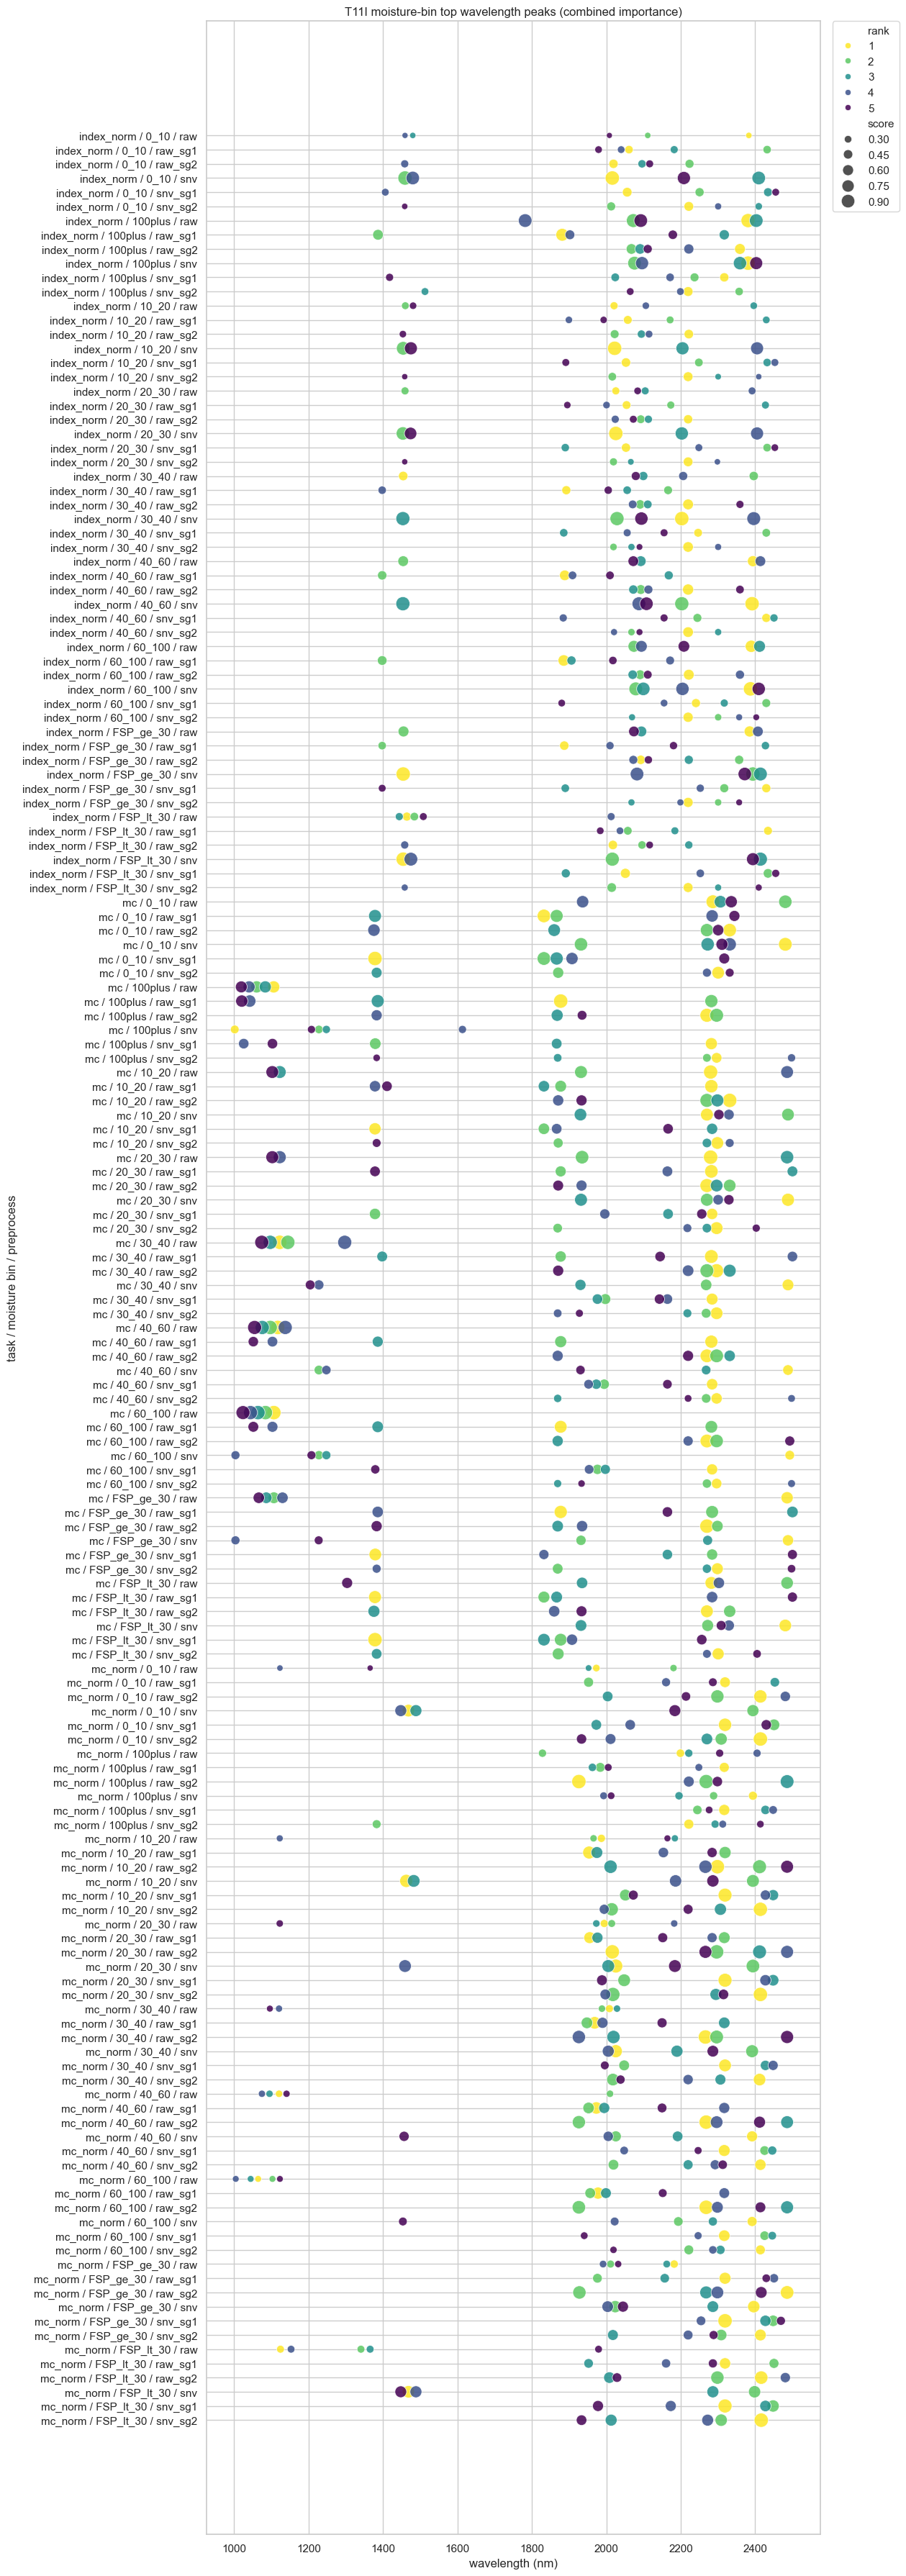

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\figures\T11I_moisture_bin_top_wavelength_peak_heatmap.png


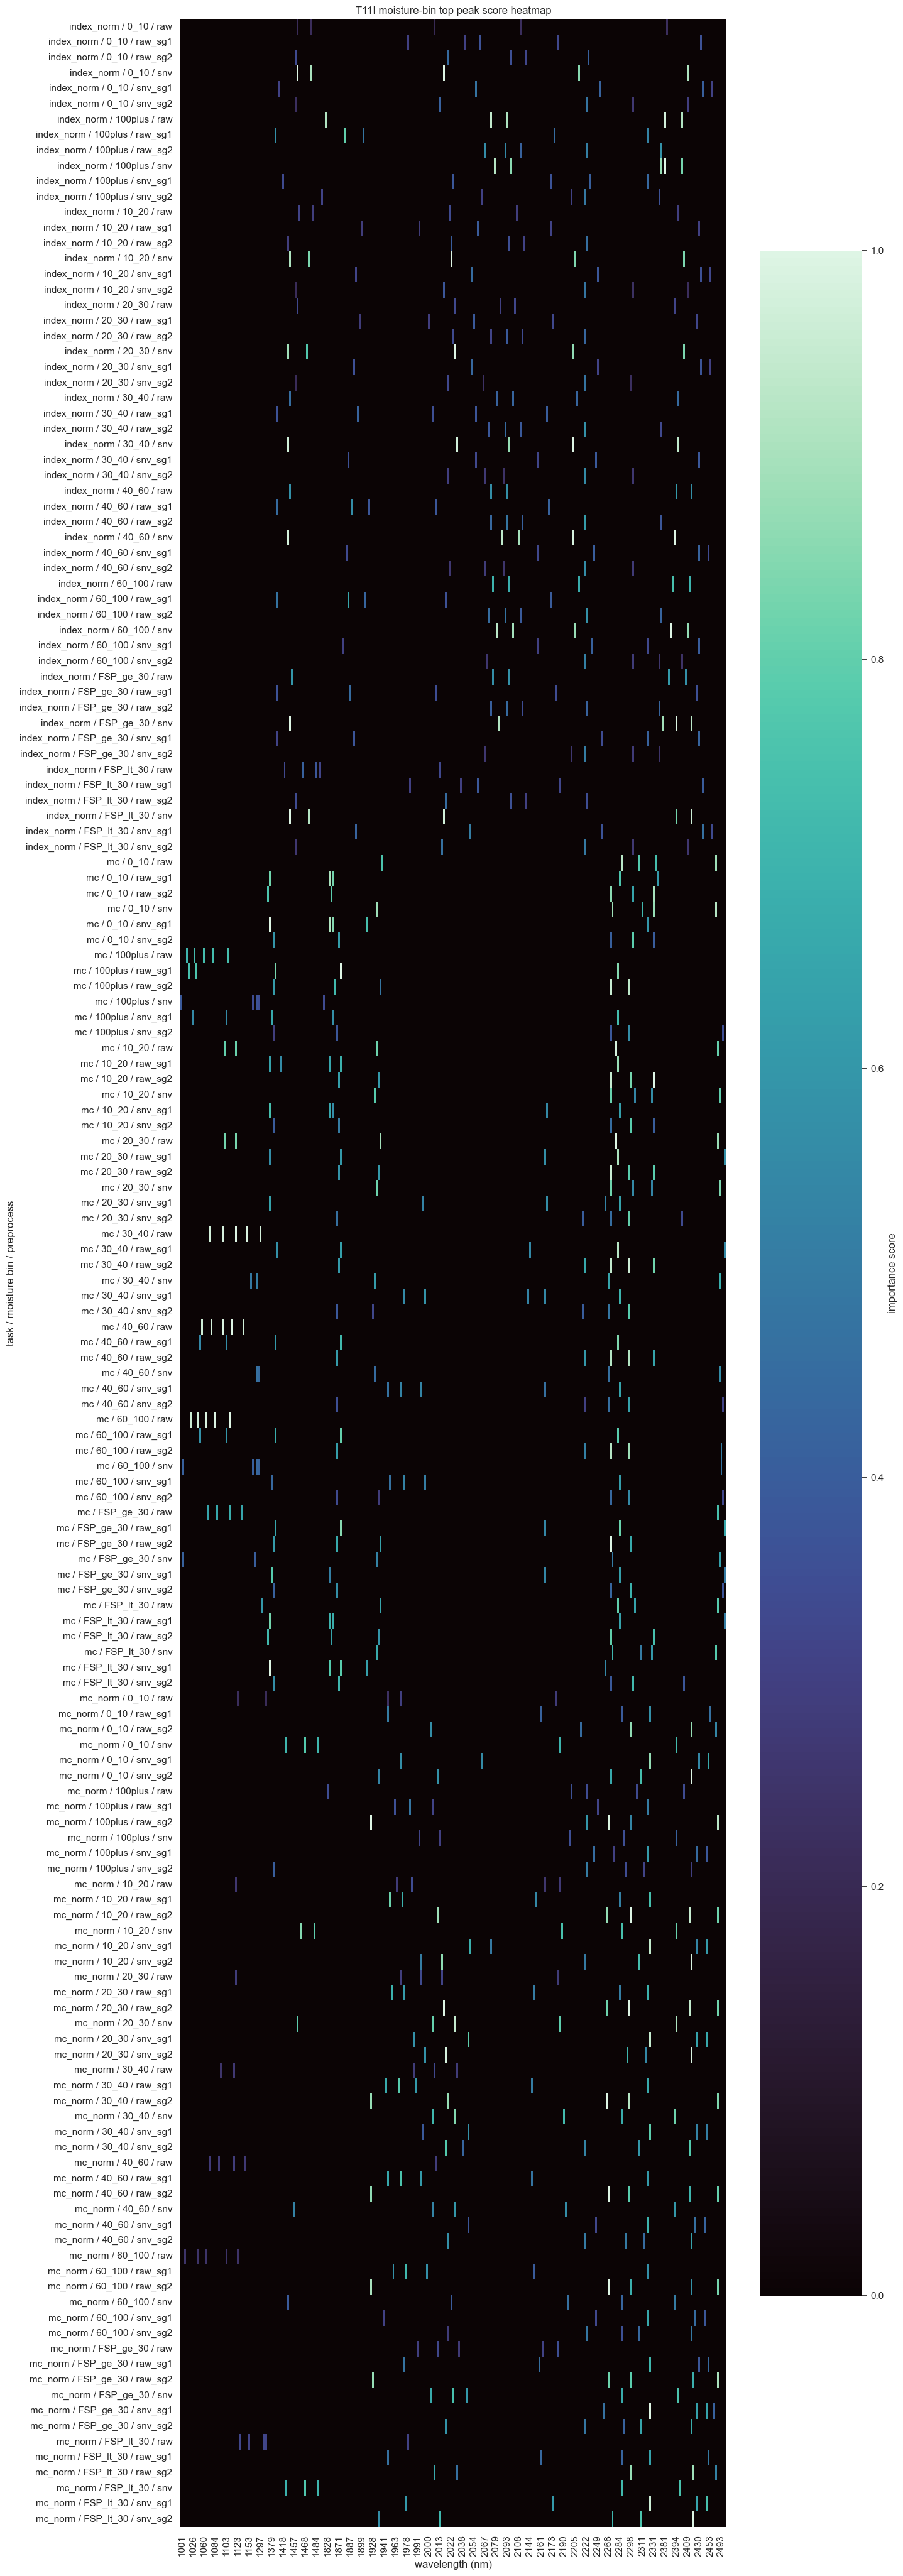

In [11]:
if not t11i_top_peaks_by_preprocess_df.empty:
    t11i_plot = t11i_top_peaks_by_preprocess_df[
        (t11i_top_peaks_by_preprocess_df["task"].isin(MOISTURE_TASKS))
        & (t11i_top_peaks_by_preprocess_df["method"] == "T11I_combined_importance_saliency_ig")
        & (t11i_top_peaks_by_preprocess_df["rank"] <= 5)
    ].copy()
    t11i_plot["row_label"] = t11i_plot["task"] + " / " + t11i_plot["moisture_bin"] + " / " + t11i_plot["preprocess"]
    plt.figure(figsize=(11, max(5, 0.28 * t11i_plot["row_label"].nunique())))
    sns.scatterplot(data=t11i_plot, x="wavelength_nm", y="row_label", size="score", hue="rank", palette="viridis_r", sizes=(35, 200), alpha=0.85)
    plt.title("T11I moisture-bin top wavelength peaks (combined importance)")
    plt.xlabel("wavelength (nm)")
    plt.ylabel("task / moisture bin / preprocess")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    savefig("T11I_moisture_bin_top_wavelength_peaks_scatter.png")
    plt.show()
    plt.close("all")

    heat_df = t11i_plot.copy()
    heat_df["wavelength_bin"] = heat_df["wavelength_nm"].round(0).astype(int)
    heat = heat_df.pivot_table(index="row_label", columns="wavelength_bin", values="score", aggfunc="max", fill_value=0)
    plt.figure(figsize=(14, max(5, 0.32 * len(heat))))
    sns.heatmap(heat, cmap="mako", cbar_kws={"label": "importance score"})
    plt.title("T11I moisture-bin top peak score heatmap")
    plt.xlabel("wavelength (nm)")
    plt.ylabel("task / moisture bin / preprocess")
    savefig("T11I_moisture_bin_top_wavelength_peak_heatmap.png")
    plt.show()
    plt.close("all")

## Visualization

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\figures\T11_moisture_top_wavelength_peaks_scatter.png


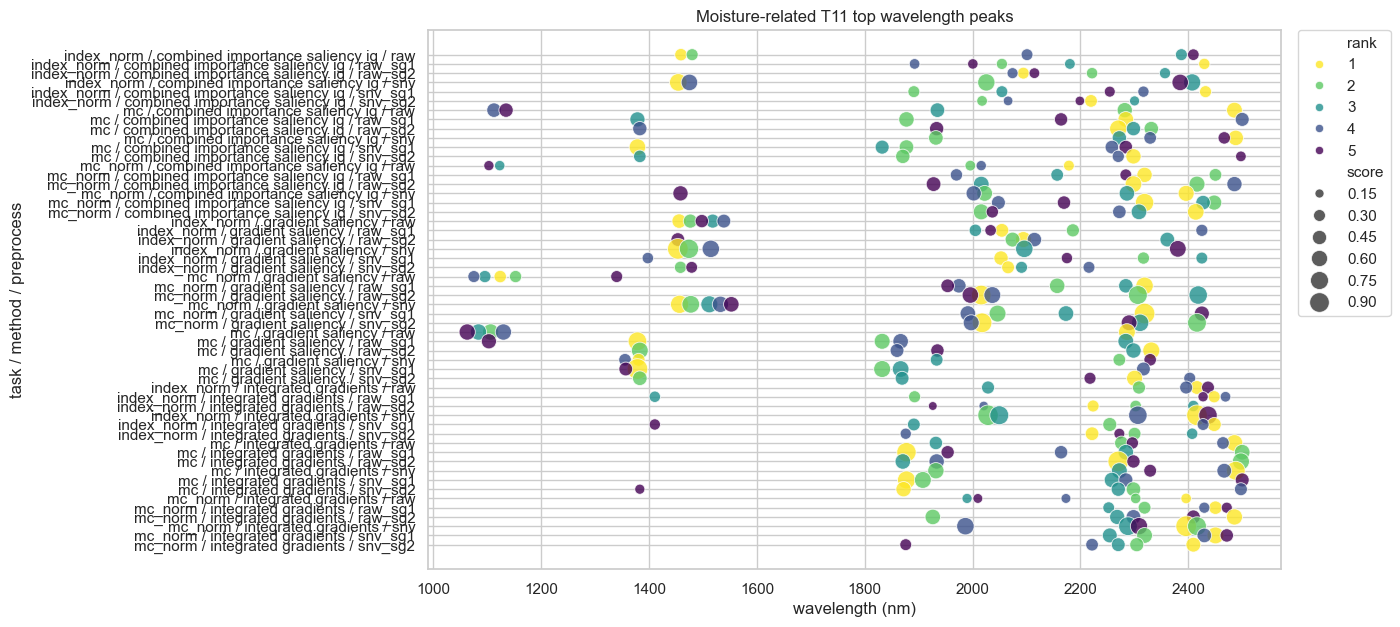

saved: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables\figures\T11_moisture_top_wavelength_peak_heatmap.png


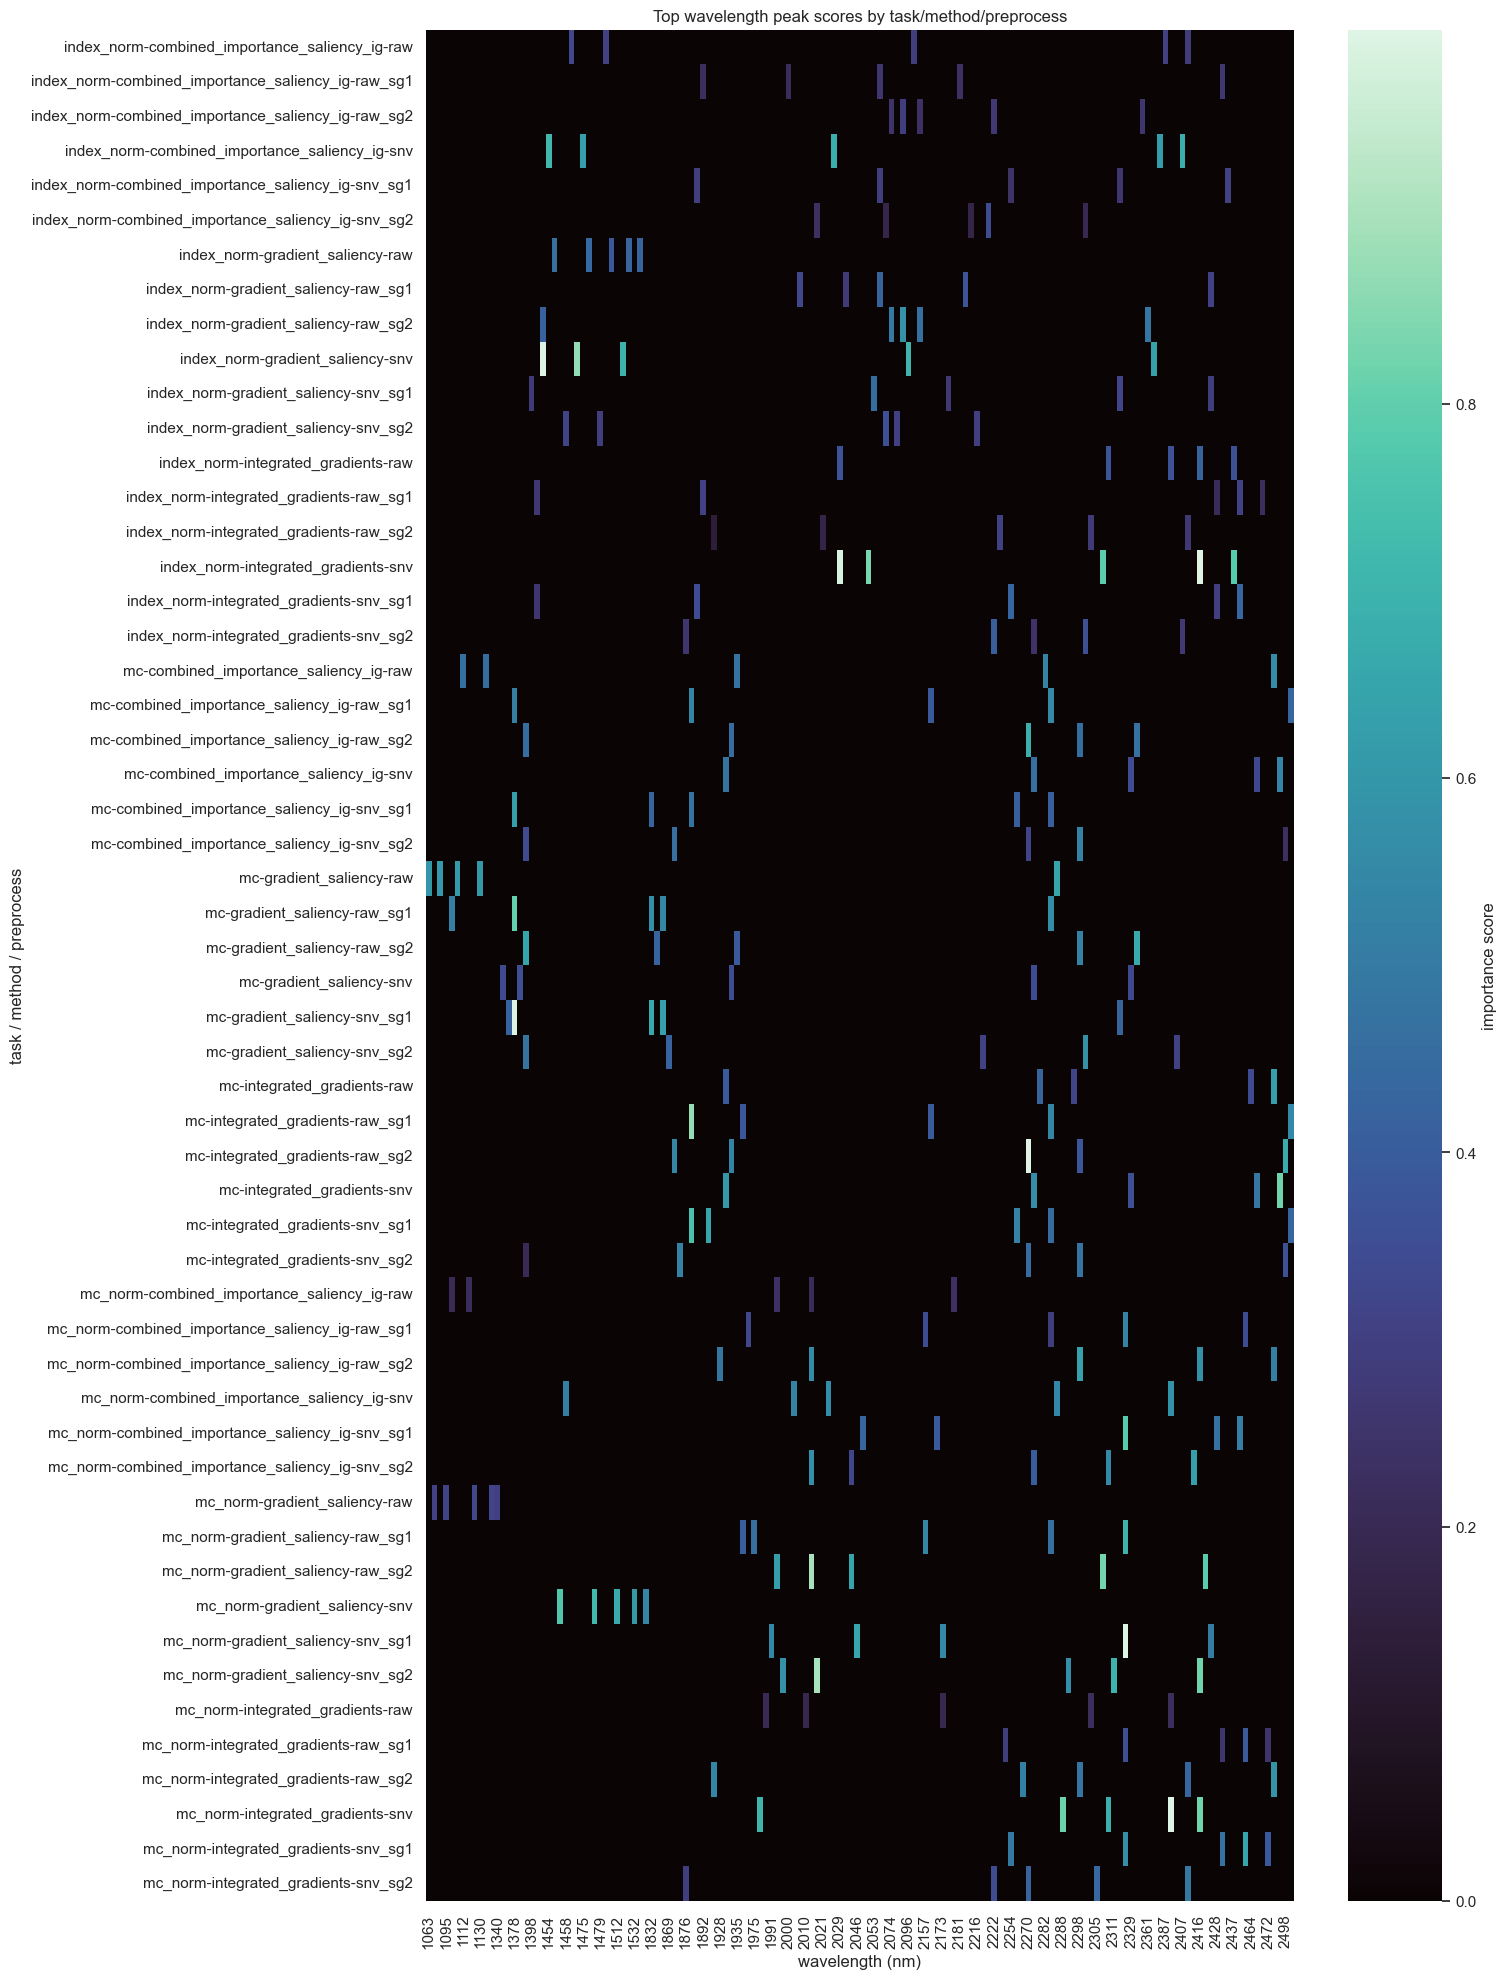

In [12]:
plot_df = moisture_top_peaks_by_preprocess[moisture_top_peaks_by_preprocess["rank"] <= 5].copy()
plot_df["label"] = plot_df["task"] + " / " + plot_df["method"].str.replace("_", " ") + " / " + plot_df["preprocess"]
plt.figure(figsize=(11, 7))
sns.scatterplot(data=plot_df, x="wavelength_nm", y="label", size="score", hue="rank", palette="viridis_r", sizes=(40, 220), alpha=0.8)
plt.title("Moisture-related T11 top wavelength peaks")
plt.xlabel("wavelength (nm)")
plt.ylabel("task / method / preprocess")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
savefig("T11_moisture_top_wavelength_peaks_scatter.png")
plt.show()
plt.close("all")

heat_df = moisture_top_peaks_by_preprocess[moisture_top_peaks_by_preprocess["rank"] <= 5].copy()
heat_df["wavelength_bin"] = heat_df["wavelength_nm"].round(0).astype(int)
heat = heat_df.pivot_table(index=["task", "method", "preprocess"], columns="wavelength_bin", values="score", aggfunc="max", fill_value=0)
plt.figure(figsize=(14, max(4, 0.45 * len(heat))))
sns.heatmap(heat, cmap="mako", cbar_kws={"label": "importance score"})
plt.title("Top wavelength peak scores by task/method/preprocess")
plt.xlabel("wavelength (nm)")
plt.ylabel("task / method / preprocess")
savefig("T11_moisture_top_wavelength_peak_heatmap.png")
plt.show()
plt.close("all")

## Notes

In [13]:
print("Notes")
print("- importance score: CSV の importance / heatmaps / saliency / integrated gradients を同じスケール内で順位付けしています。saliency/IG は絶対値を使います。")
print("- band occlusion score: prediction_drop があればそれを優先し、なければ取得できる数値列をスコアとして使います。")
print("- top_peaks は近接波長の重複を避けるため、原則 20nm 以上離れたピークを抽出します。")
if "t11i_top_peaks_df" in globals() and not t11i_top_peaks_df.empty:
    print("- T11I moisture-bin outputs は outputs/wood-moisture-2d-cnn-outputs-moisture-bins から追加集計しました。")
else:
    print("- T11I moisture-bin outputs は見つからなかったため、この notebook ではスキップしました。")
print("Output:", OUTPUT_DIR)


Notes
- importance score: CSV の importance / heatmaps / saliency / integrated gradients を同じスケール内で順位付けしています。saliency/IG は絶対値を使います。
- band occlusion score: prediction_drop があればそれを優先し、なければ取得できる数値列をスコアとして使います。
- top_peaks は近接波長の重複を避けるため、原則 20nm 以上離れたピークを抽出します。
- T11I moisture-bin outputs は outputs/wood-moisture-2d-cnn-outputs-moisture-bins から追加集計しました。
Output: C:\Users\aikoc\PythonProjectFolder\SIGNATE\NIR_CNN_2D\outputs\T11_top_wavelength_tables
